In [1]:
import torch 
from torch import nn as nn 
import albumentations as A 
from PIL import Image
from albumentations.pytorch import ToTensorV2
import os 
import numpy as np 
from torch.utils.data import Dataset

train_transform_img = A.Compose(
    [
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.RandomCrop(height=256, width=256),
        A.RandomBrightnessContrast(p=0.5),
        ToTensorV2(),
    ]
)

In [18]:
class SegmentationDataset(Dataset):
    def __init__(self, img_path) -> None:
        super().__init__()
        self.img_files = [img_path + i for  i in  os.listdir(img_path)]
        self.mask_files = [i.replace("image", "mask") for i in self.img_files]
        
    def __len__(self):
        return len(self.img_files)
    
    def __getitem__(self, index):
        img_file = self.img_files[index]
        mask_file = self.mask_files[index]
        
        img = Image.open(img_file)
        mask = Image.open(mask_file)
        img = np.array(img)
        mask = np.array(mask)
        
        res =  train_transform_img(image = img, mask = mask)
        img = res["image"]
        mask = res["mask"]
        mask = mask.unsqueeze(0)
        # img = img.unsqueeze(0)
        imgs = [img[:, :128, :128], img[:, :128, 128:256], img[:, 128:256, 128:256], img[:, 128:256, :128]]
        masks = [mask[:, :128, :128], mask[:, :128, 128:256], mask[:, 128:256, 128:256], mask[:, 128:256, :128]]
        # print(imgs[0].shape )
        imgs = torch.cat([img.unsqueeze(0) for img in imgs], dim=0)
        masks = torch.cat([mask.unsqueeze(0) for mask in masks], dim = 0)
        masks = (masks / 63).ceil().long()
        return imgs, masks 

In [19]:
sd = SegmentationDataset('/home/kathy/projects/project_guo/train/image/')

In [20]:
imgs, mask = next(iter(sd))

In [25]:
torch.unique(mask)

tensor([0, 1, 2, 3, 4])

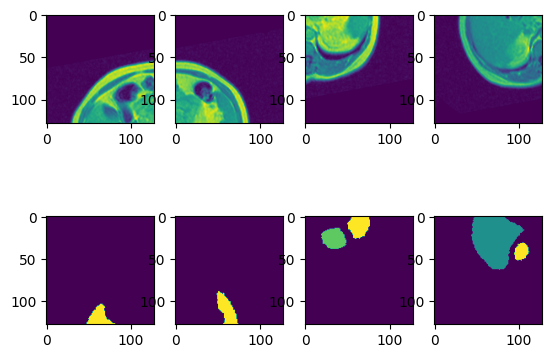

In [24]:
def visualization(imgs, masks):
    fig, axes = plt.subplots(2, 4)
    # fig.se(10, 8)
    for i in range(4):
        axes[0, i].imshow(imgs[i][0].numpy())
        axes[1, i].imshow(masks[i][0].numpy())
visualization(imgs, mask)

In [12]:
len(os.listdir('/home/kathy/projects/project_guo/train/image/')) * 4 * (1 / 4)

647.0

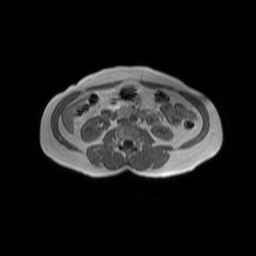

In [5]:
img = Image.open('/home/kathy/projects/project_guo/train/image/10_3.png')
mask = Image.open('/home/kathy/projects/project_guo/train/mask/10_3.png')
img 

In [6]:
np.unique(np.array(img))

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [7]:
np.unique(np.array(mask))

array([  0,  63, 126, 189], dtype=uint8)

In [8]:
import numpy as np 

res = train_transform_img(image = np.array(img), mask = np.array(mask))

In [9]:
res["image"].shape 

torch.Size([1, 256, 256])

In [10]:
res["mask"].shape 


torch.Size([256, 256])

In [11]:
from matplotlib import pyplot as plt 

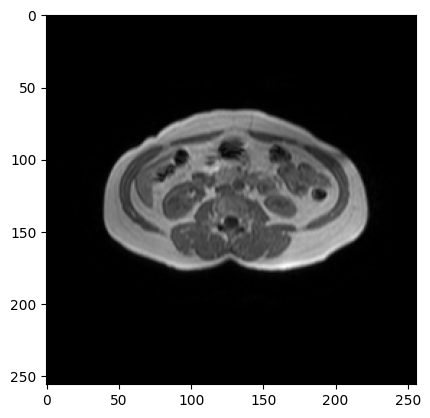

In [12]:
plt.imshow(res["image"].squeeze(0), cmap = "gray")

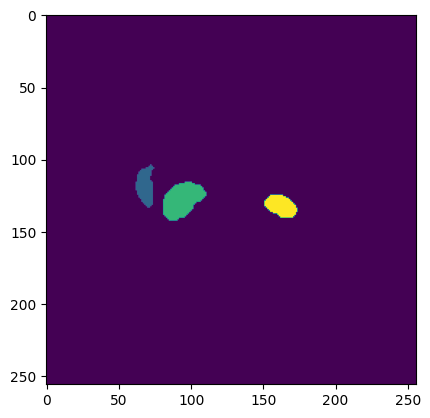

In [13]:
plt.imshow(res["mask"])


In [17]:
np.ceil(np.unique(res["mask"]) // 63)

array([0., 1., 2., 3.], dtype=float16)